# Solution: Gradient Descent for Linear Regression

This notebook fits a straight line with mean squared error (MSE), first using an analytical gradient and then a centered finite-difference numerical gradient. We generate 10 observations around $y=2x+1$, with random noise in both the measured $x$ and $y$ values. A fixed seed makes the data repeatable, and the fitted parameters should be reasonably close to $w=2$ and $b=1$.

Think of loss as a landscape: gradient descent is like hiking downhill in fog, using the local slope to choose a direction. It is useful because model parameters can be optimized iteratively even when the best values are not obvious by inspection.

## 1. Understand the objective

For prediction $\hat{y}_i=wx_i+b$, define residual $e_i=wx_i+b-y_i$. The mean squared error is

$$L(w,b)=\frac{1}{n}\sum_{i=1}^{n}e_i^2.$$

By the chain rule, $\partial e_i/\partial w=x_i$ and $\partial e_i/\partial b=1$, so

$$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_i e_i x_i, \qquad \frac{\partial L}{\partial b}=\frac{2}{n}\sum_i e_i.$$

Gradient descent subtracts a learning-rate-scaled gradient because the gradient points toward increasing loss.

## 2. Set up the training data

The reproducible sample contains 10 observations around $y=2x+1$, with noise in both the measured input and target. The scatter plot below shows the data used throughout this solution.

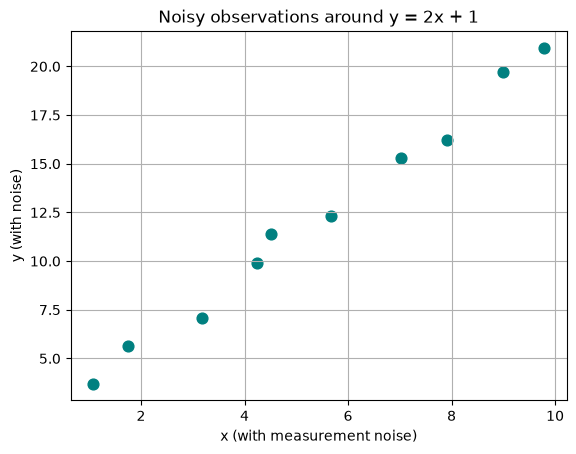

In [17]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x_base = np.linspace(1.0, 10.0, 10)
X = x_base + rng.normal(0.0, 0.25, size=10)
y = 2.0 * x_base + 1.0 + rng.normal(0.0, 0.8, size=10)

plt.scatter(X, y, color="teal", s=60)
plt.xlabel("x (with measurement noise)")
plt.ylabel("y (with noise)")
plt.title("Noisy observations around y = 2x + 1")
plt.grid(True)
plt.show()

## 3. Implement the loss function

The loss is the mean of the squared residuals, not their sum. Averaging keeps the scale of the loss and gradient from growing just because there are more samples. Since the observations include noise, even the generating line $y=2x+1$ will have nonzero MSE.

In [9]:
print("MSE at the generating parameters:", mse_loss(2.0, 1.0, X, y))

MSE at the generating parameters: 0.4800594534012575


## 4. Derive and implement the analytical gradient

The residual is prediction minus target. Therefore both gradient components use the same residuals, with $x_i$ multiplying the slope component.

In [10]:
def analytical_gradient(w, b, X, y):
    residuals = w * X + b - y
    dL_dw = 2 * np.mean(residuals * X)
    dL_db = 2 * np.mean(residuals)
    return dL_dw, dL_db

print("Initial analytical gradient:", analytical_gradient(0.0, 0.0, X, y))

Initial analytical gradient: (np.float64(-163.57624181959076), np.float64(-24.431531402842296))


## 5. Estimate the gradient numerically

For each parameter, evaluate the loss a small distance on either side and divide the difference by $2\epsilon$. This approximates a derivative without manually deriving it. The estimate depends on a sensible epsilon: extremely large values are less local, while extremely small values can amplify floating-point error.

In [11]:
def numerical_gradient(w, b, X, y, epsilon=1e-5):
    dL_dw = (mse_loss(w + epsilon, b, X, y) - mse_loss(w - epsilon, b, X, y)) / (2 * epsilon)
    dL_db = (mse_loss(w, b + epsilon, X, y) - mse_loss(w, b - epsilon, X, y)) / (2 * epsilon)
    return dL_dw, dL_db

analytic = analytical_gradient(0.0, 0.0, X, y)
numeric = numerical_gradient(0.0, 0.0, X, y)
print("Analytical gradient:", analytic)
print("Numerical gradient: ", numeric)
print("Absolute difference:", np.abs(np.array(analytic) - np.array(numeric)))

Analytical gradient: (np.float64(-163.57624181959076), np.float64(-24.431531402842296))
Numerical gradient:  (np.float64(-163.57624181893016), np.float64(-24.431531400637137))
Absolute difference: [6.60605792e-10 2.20515872e-09]


## 6. Train with analytical gradients

Each epoch computes gradients at the current parameter values and then updates both parameters. The loss history records the loss after each update.

Learned w: 1.9466
Learned b: 1.6684
Final MSE: 0.30753388


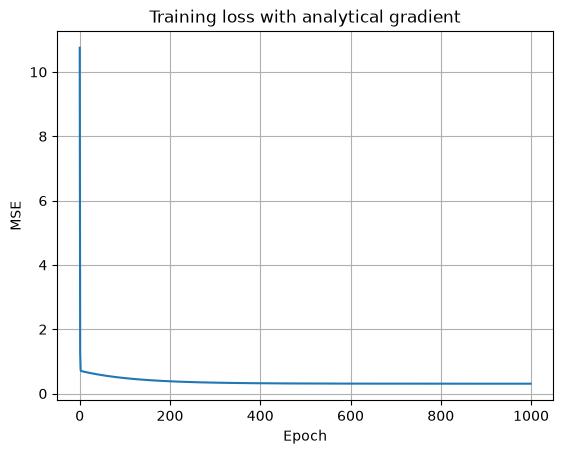

In [12]:
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
loss_history = []

for epoch in range(epochs):
    dL_dw, dL_db = analytical_gradient(w, b, X, y)
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db
    loss_history.append(mse_loss(w, b, X, y))

print(f"Learned w: {w:.4f}")
print(f"Learned b: {b:.4f}")
print(f"Final MSE: {mse_loss(w, b, X, y):.8f}")

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training loss with analytical gradient")
plt.grid(True)
plt.show()

## 7. Train using numerical gradients

The optimization loop is unchanged; only the source of the gradient differs. Each numerical gradient requires four loss evaluations for two parameters, which is more computation than the analytical calculation.

Numerical-gradient w: 1.9466
Numerical-gradient b: 1.6684
Final MSE: 0.30753388
Maximum loss-history difference: 3.9264591578103136e-10


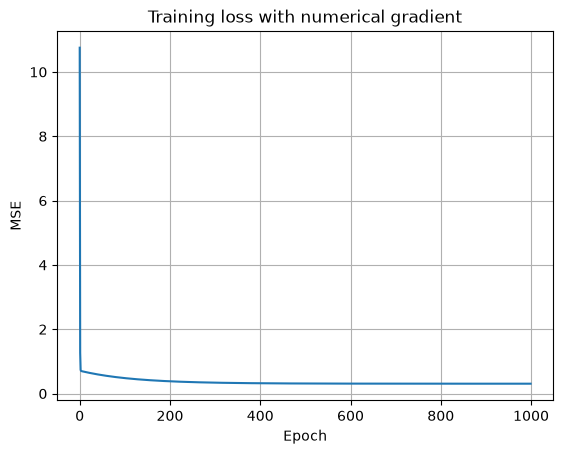

In [15]:
w_num = 0.0
b_num = 0.0
numerical_losses = []

for epoch in range(epochs):
    dL_dw, dL_db = numerical_gradient(w_num, b_num, X, y)
    w_num -= learning_rate * dL_dw
    b_num -= learning_rate * dL_db
    numerical_losses.append(mse_loss(w_num, b_num, X, y))

print(f"Numerical-gradient w: {w_num:.4f}")
print(f"Numerical-gradient b: {b_num:.4f}")
print(f"Final MSE: {mse_loss(w_num, b_num, X, y):.8f}")
print("Maximum loss-history difference:", np.max(np.abs(np.array(loss_history) - np.array(numerical_losses))))

plt.plot(numerical_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training loss with numerical gradient")
plt.grid(True)
plt.show()

## 8. Explore the learning rate

A small learning rate makes modest progress per update. A larger one may converge more quickly, but if it is too large the parameters can overshoot and the loss can grow or diverge. The plot uses a logarithmic y-axis so both steady progress and rapid loss growth are visible. The unstable run stops at a finite display limit to avoid numeric overflow.

learning_rate=0.001: final MSE=0.681930
learning_rate=0.01: final MSE=0.482543
learning_rate=0.5: diverged


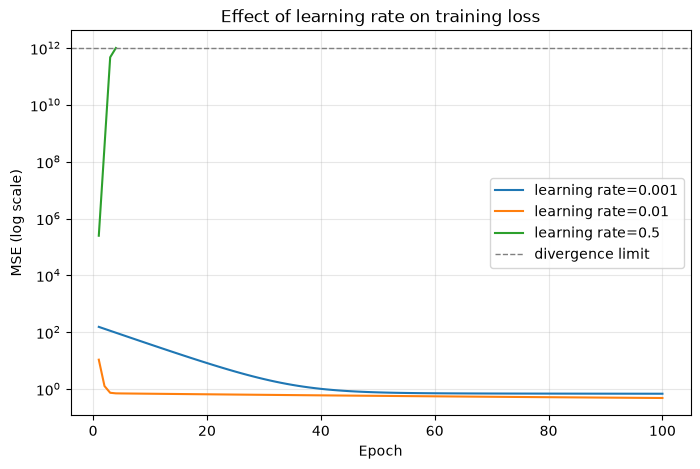

In [18]:
loss_limit = 1e12
rate_histories = {}

for rate in [0.001, 0.01, 0.5]:
    trial_w = 0.0
    trial_b = 0.0
    rate_losses = []
    diverged = False

    for epoch in range(100):
        dL_dw, dL_db = analytical_gradient(trial_w, trial_b, X, y)
        trial_w -= rate * dL_dw
        trial_b -= rate * dL_db

        with np.errstate(over="ignore", invalid="ignore"):
            current_loss = mse_loss(trial_w, trial_b, X, y)

        if not np.isfinite(current_loss) or current_loss > loss_limit:
            rate_losses.append(loss_limit)
            diverged = True
            break

        rate_losses.append(current_loss)

    rate_histories[rate] = rate_losses
    status = "diverged" if diverged else f"final MSE={rate_losses[-1]:.6f}"
    print(f"learning_rate={rate}: {status}")

plt.figure(figsize=(8, 5))
for rate, losses in rate_histories.items():
    plt.semilogy(range(1, len(losses) + 1), losses, label=f"learning rate={rate}")
plt.axhline(loss_limit, color="gray", linestyle="--", linewidth=1, label="divergence limit")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Effect of learning rate on training loss")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Key takeaways

- MSE measures the average squared prediction error.
- The analytical gradient follows directly from the chain rule.
- Centered finite differences estimate the gradient from loss evaluations.
- Automatic differentiation applies the chain rule through recorded operations; it is generally more efficient than finite differences for large models.
- Gradient descent subtracts the gradient, scaled by the learning rate.
- Analytical gradients are efficient when available; numerical gradients are useful for checking derivatives or when deriving them is inconvenient.